In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax import nnx
from torchvision import transforms
from torchvision.datasets import MNIST

from mltg import training

In [2]:
# Download MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: jnp.array(x.numpy(), dtype=jnp.float32)),
])

train_dataset = MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = MNIST(root="./data", train=False, download=True, transform=transform)

# Convert to JAX arrays
train_images = jnp.array(train_dataset.data.numpy(), dtype=jnp.float32)
train_labels = jnp.array(train_dataset.targets.numpy(), dtype=jnp.int32)
test_images = jnp.array(test_dataset.data.numpy(), dtype=jnp.float32)
test_labels = jnp.array(test_dataset.targets.numpy(), dtype=jnp.int32)

print(f"Train images shape: {train_images.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In [3]:
# Normalize and reshape images
train_images = train_images / 255.0
test_images = test_images / 255.0

# Flatten images from (N, 1, 28, 28) to (N, 784)
train_images = train_images.reshape(train_images.shape[0], -1)
test_images = test_images.reshape(test_images.shape[0], -1)

print(f"Train images shape after flatten: {train_images.shape}")

Train images shape after flatten: (60000, 784)


In [4]:
# Define the neural network model using Flax nnx
class MLP(nnx.Module):
    def __init__(
            self,
            input_dim: int,
            hidden_dim: int,
            output_dim: int,
            *,
            rngs: nnx.Rngs
    ) -> None:
        self.linear1 = nnx.Linear(input_dim, hidden_dim, rngs=rngs)
        self.linear2 = nnx.Linear(hidden_dim, output_dim, rngs=rngs)

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jax.nn.relu(self.linear1(x))
        return self.linear2(x)

In [5]:
# Initialize model and optimizer
rngs = nnx.Rngs(42)
model = MLP(784, 128, 10, rngs=rngs)
nnx.display(model)


# Define loss function
def loss_fn(
        model: nnx.Module,
        x: jax.Array,
        y: jax.Array
) -> jax.Array:
    logits = model(x)
    return optax.softmax_cross_entropy_with_integer_labels(
        logits,
        y
    ).mean()


# Define accuracy function
def accuracy_fn(model: nnx.Module, x: jax.Array, y: jax.Array) -> jax.Array:
    logits = model(x)
    predictions = jnp.argmax(logits, axis=1)
    return jnp.mean(predictions == y)

In [6]:
# Training loop
batch_size = 64
num_epochs = 20

# Create optimizer
adam = optax.adam(learning_rate=0.001)
optimizer = nnx.Optimizer(model, adam, wrt=nnx.Param)

train_losses, train_accuracies, test_losses, test_accuracies = training.train(
    model,
    optimizer,
    loss_fn,
    accuracy_fn,
    num_epochs,
    batch_size,
    (train_images, train_labels, test_images, test_labels)
)

Epoch 1/20: train_loss=0.3200, train_acc=0.9171, test_loss=0.1668, test_acc=0.9510
Epoch 2/20: train_loss=0.1422, train_acc=0.9615, test_loss=0.1279, test_acc=0.9605
Epoch 3/20: train_loss=0.1009, train_acc=0.9736, test_loss=0.1039, test_acc=0.9681
Epoch 4/20: train_loss=0.0769, train_acc=0.9795, test_loss=0.0859, test_acc=0.9736
Epoch 5/20: train_loss=0.0613, train_acc=0.9843, test_loss=0.0797, test_acc=0.9754
Epoch 6/20: train_loss=0.0493, train_acc=0.9879, test_loss=0.0718, test_acc=0.9781
Epoch 7/20: train_loss=0.0401, train_acc=0.9911, test_loss=0.0728, test_acc=0.9778
Epoch 8/20: train_loss=0.0323, train_acc=0.9936, test_loss=0.0794, test_acc=0.9757
Epoch 9/20: train_loss=0.0276, train_acc=0.9946, test_loss=0.0728, test_acc=0.9770
Epoch 10/20: train_loss=0.0217, train_acc=0.9960, test_loss=0.0695, test_acc=0.9807
Epoch 11/20: train_loss=0.0181, train_acc=0.9974, test_loss=0.0747, test_acc=0.9799
Epoch 12/20: train_loss=0.0155, train_acc=0.9978, test_loss=0.0782, test_acc=0.9785
E

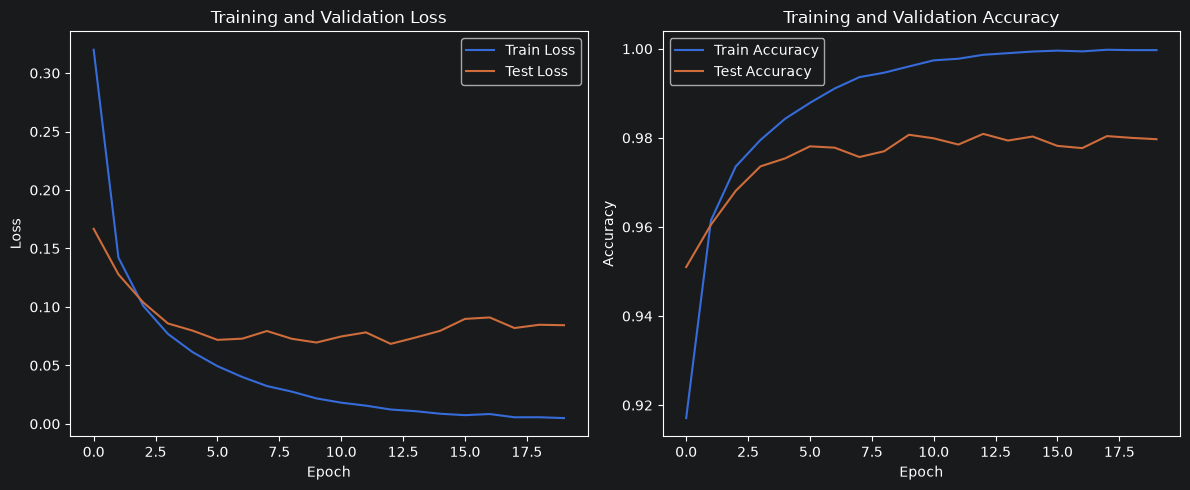

In [7]:
# Plot training and validation curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")

plt.tight_layout()
plt.show()

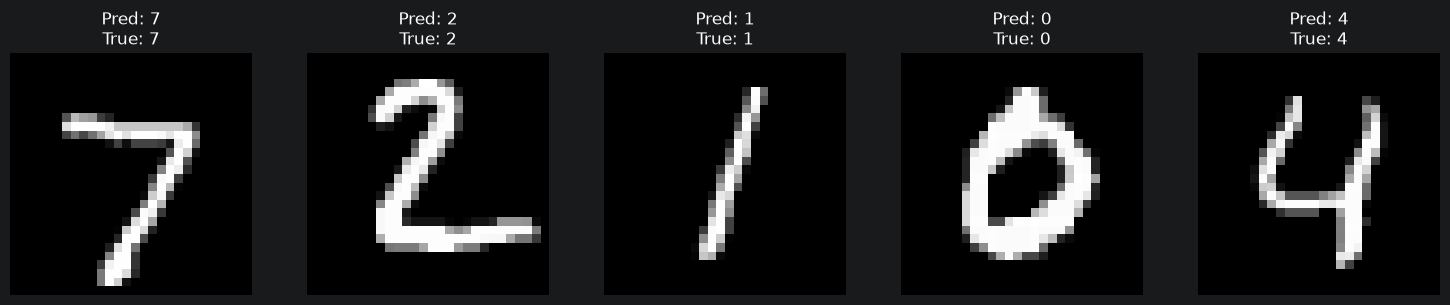

In [9]:
# Visualize some predictions
def show_predictions(
        model: nnx.Module,
        images: jax.Array,
        labels: jax.Array,
        num_samples: int = 5
) -> None:
    logits = model(images[:num_samples])
    predictions = jnp.argmax(logits, axis=1)
    true_labels = labels[:num_samples]

    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap="gray")
        plt.title(f"Pred: {predictions[i]}\nTrue: {true_labels[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_predictions(model, test_images, test_labels)

In [10]:
# Final evaluation
eval_step = training.get_eval_step(loss_fn, accuracy_fn)
final_test_loss, final_test_acc = eval_step(model, test_images, test_labels)
print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.4f}")

Final Test Loss: 0.0844
Final Test Accuracy: 0.9797
